DATA LOADING

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


EDA

In [101]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


array([[<Axes: title={'center': 'person_age'}>,
        <Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'person_emp_length'}>],
       [<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'loan_int_rate'}>,
        <Axes: title={'center': 'loan_status'}>],
       [<Axes: title={'center': 'loan_percent_income'}>,
        <Axes: title={'center': 'cb_person_cred_hist_length'}>, <Axes: >]],
      dtype=object)

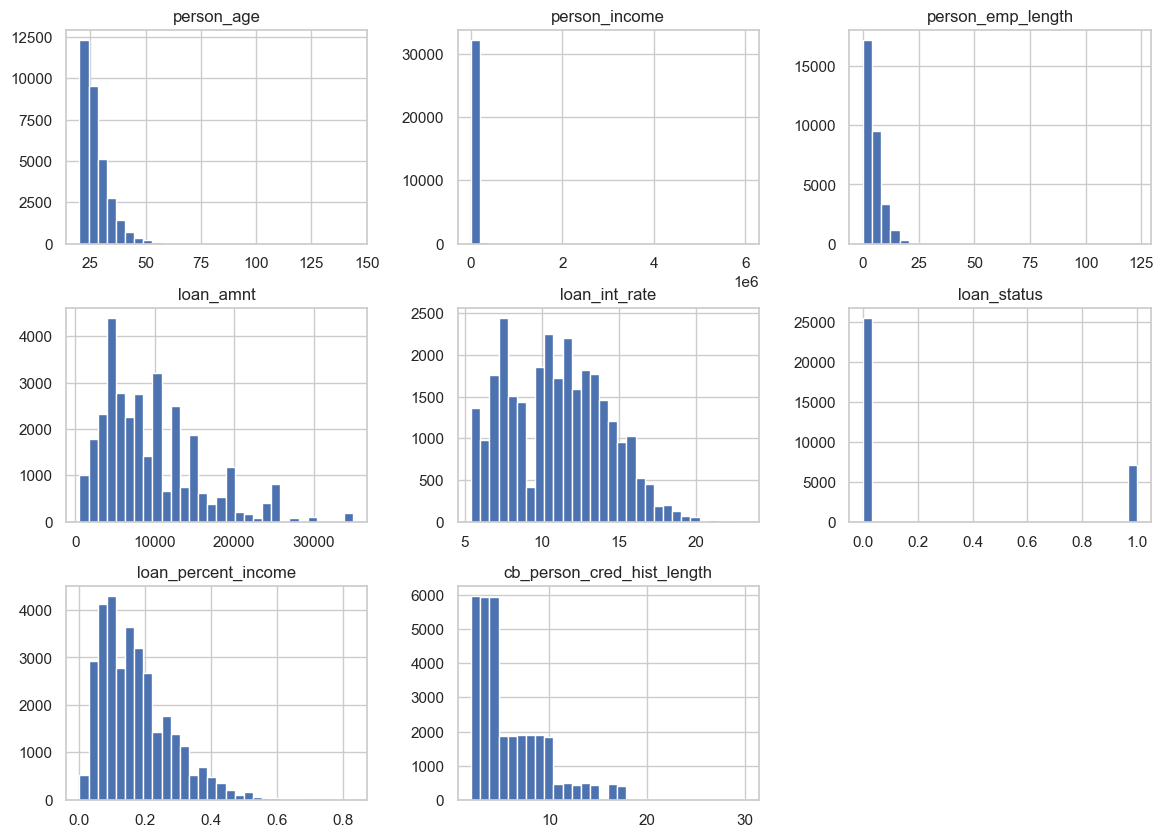

In [102]:
df.hist(bins=30, figsize=(14, 10))

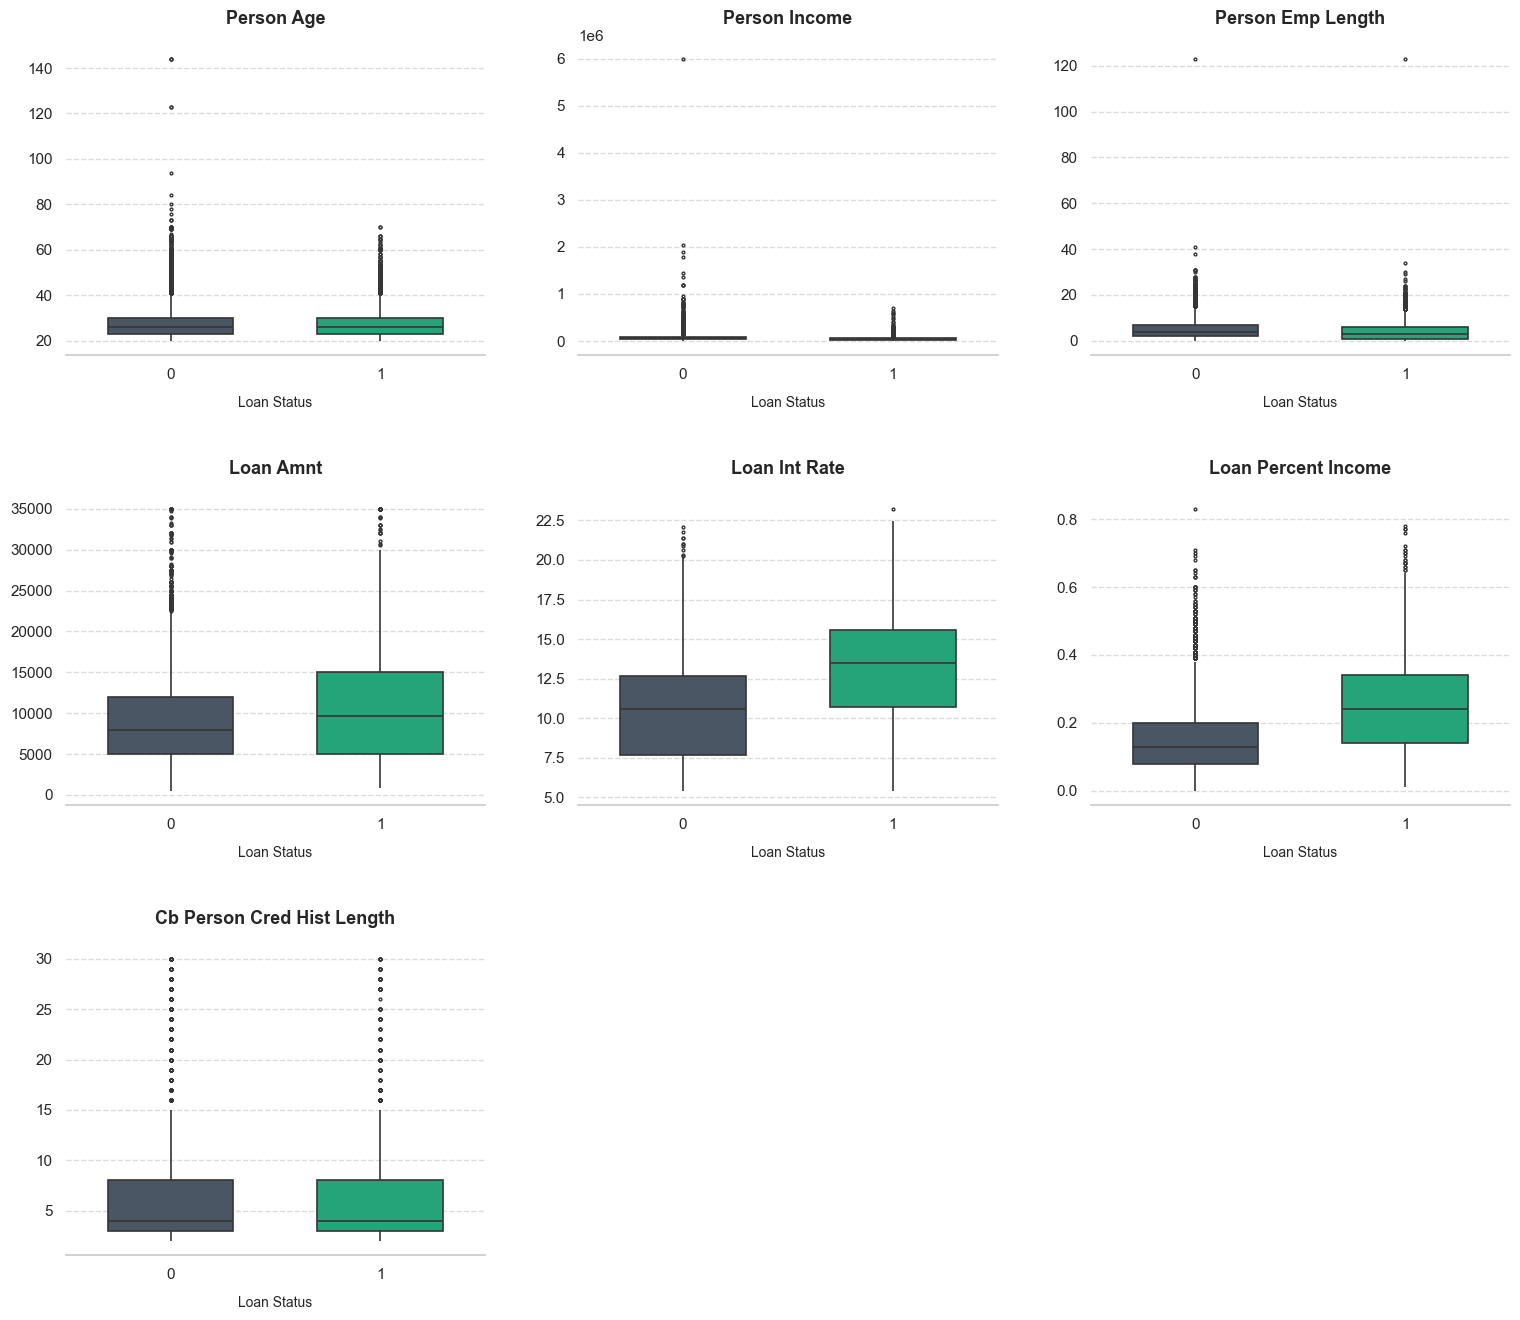

In [103]:
sns.set_theme(style="whitegrid", font_scale=1)
plt.rcParams['font.family'] = 'sans-serif'

numerical_features = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
palette = {0: '#475569', 1: '#10B981'}

for i, feature in enumerate(numerical_features):
    sns.boxplot(x='loan_status', y=feature, data=df, hue='loan_status', legend=False, width=0.6,palette=palette,
        linewidth=1.2, fliersize=2, ax=axes[i],showcaps=False
    )

    # Title and Label styling
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=13, fontweight='bold', pad=15)
    axes[i].set_xlabel('Loan Status', fontsize=10, labelpad=10)
    axes[i].set_ylabel('') # Removing Y-label as the title covers it   fb
    sns.despine(ax=axes[i], left=True)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)


for x in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[x])

plt.tight_layout(pad=3.0)
plt.show()


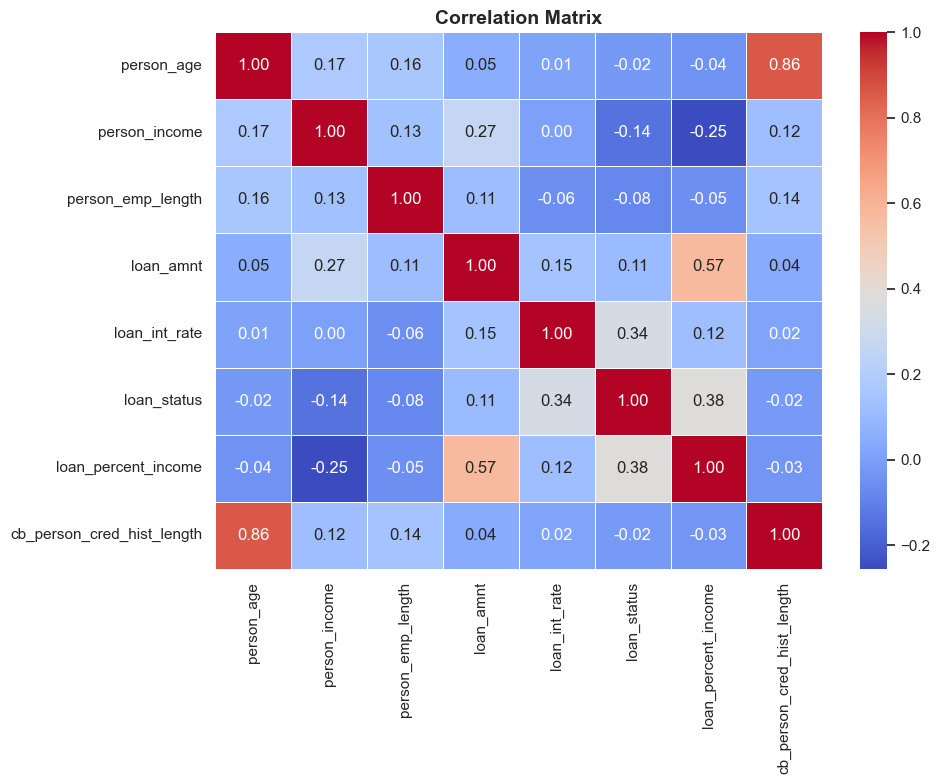

In [104]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [105]:
df.isnull().sum() # Computes the number of null values in data set

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [106]:
df.isnull().mean() * 100 # Computes the percentages of all values with null values

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [107]:
# Count and percentage of missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent.round(2)})

# Only show columns that have missing values
missing_table = missing_table[missing_table['Missing Count'] > 0]
print(missing_table)

                   Missing Count  Missing Percentage (%)
person_emp_length            895                    2.75
loan_int_rate               3116                    9.56


/var/folders/v2/2hgjvxh116gd4gxk_0bjm7m40000gn/T/ipykernel_53507/1024777308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_table.index,


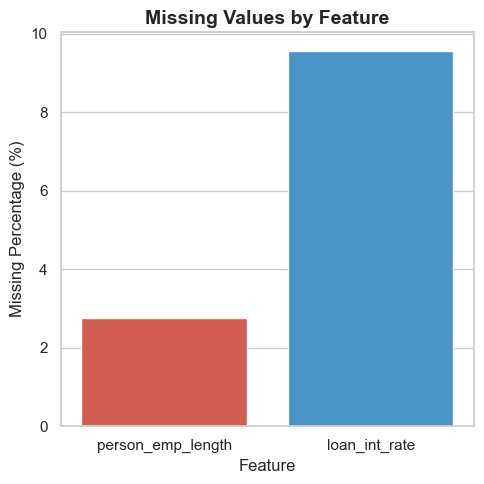

In [108]:
plt.figure(figsize=(5, 5))
sns.barplot(x=missing_table.index,
            y=missing_table['Missing Percentage (%)'],
            palette=['#e74c3c', '#3498db'])

plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.tight_layout()
plt.show()

MAR for  ```loan_int_rate```


In [116]:
df['int_rate_missing'] = df['loan_int_rate'].isnull().astype(int)

print(df.groupby('loan_grade')['int_rate_missing'].mean())

loan_grade
A    0.093069
B    0.101043
C    0.097553
D    0.086045
E    0.086100
F    0.112033
G    0.078125
Name: int_rate_missing, dtype: float64


MCAR FOR ```person_emp_lenght```


In [110]:
df['emp_missing'] = df['person_emp_length'].isnull().astype(int)

print(df.groupby('loan_intent')['emp_missing'].mean())

loan_intent
DEBTCONSOLIDATION    0.028396
EDUCATION            0.025260
HOMEIMPROVEMENT      0.026352
MEDICAL              0.028661
PERSONAL             0.027531
VENTURE              0.028501
Name: emp_missing, dtype: float64


COUNTING NUMERICAL VALUES

In [111]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numerical Variables:")
print(numerical_cols.tolist())

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Variables:")
print(categorical_cols.tolist())

Numerical Variables:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'int_rate_missing', 'emp_missing']

Categorical Variables:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


LABEL ENCODING AND ONE HOT ENCODING

In [112]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Label Encoding — ordinal and binary columns
df['loan_grade_encoded'] = le.fit_transform(df['loan_grade'])
df['cb_person_default_on_file_encoded'] = le.fit_transform(df['cb_person_default_on_file'])
# One-Hot Encoding — nominal columns
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'],
                    drop_first=True)

# Check result
df.head()


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,loan_grade_encoded,cb_person_default_on_file_encoded,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,123.0,D,35000,16.02,1,0.59,Y,3,...,3,1,False,False,True,False,False,False,True,False
1,21,9600,5.0,B,1000,11.14,0,0.10,N,2,...,1,0,False,True,False,True,False,False,False,False
2,25,9600,1.0,C,5500,12.87,1,0.57,N,3,...,2,0,False,False,False,False,False,True,False,False
3,23,65500,4.0,C,35000,15.23,1,0.53,N,2,...,2,0,False,False,True,False,False,True,False,False
4,24,54400,8.0,C,35000,14.27,1,0.55,Y,4,...,2,1,False,False,True,False,False,True,False,False


IMPUTATIONS

In [119]:

# Mean imputation for loan_int_rate
mean_value = df['loan_int_rate'].mean()
df['loan_int_rate_mean'] = df['loan_int_rate'].fillna(mean_value)
print(f"Mean value used for imputation: {mean_value:.4f}")


Mean value used for imputation: 11.0117


In [120]:
# Median imputation for person_emp_length
median_value = df['person_emp_length'].median()
df['emp_length_median'] = df['person_emp_length'].fillna(median_value)
print(f"Median value used for imputation: {median_value:.4f}")

Median value used for imputation: 4.0000
